## PM Accelerator Support Mission

"By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders. This is the PM Accelerator motto, as we grant aspiring and experienced PMs what they need most—access. We introduce you to industry leaders, surround you with the right PM ecosystem, and discover the new world of AI product management skills."

## Data Cleanning and Preprocessing

In [1]:
import pandas as pd 
df = pd.read_csv('GlobalWeatherRepository.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125306 entries, 0 to 125305
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       125306 non-null  object 
 1   location_name                 125306 non-null  object 
 2   latitude                      125306 non-null  float64
 3   longitude                     125306 non-null  float64
 4   timezone                      125306 non-null  object 
 5   last_updated_epoch            125306 non-null  int64  
 6   last_updated                  125306 non-null  object 
 7   temperature_celsius           125306 non-null  float64
 8   temperature_fahrenheit        125306 non-null  float64
 9   condition_text                125306 non-null  object 
 10  wind_mph                      125306 non-null  float64
 11  wind_kph                      125306 non-null  float64
 12  wind_degree                   125306 non-nul

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
#last_updated is the timestamp feature observed
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values(by = 'last_updated')
df.set_index('last_updated', inplace = True)


In [5]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 01:45:00,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,16.1,61.0,Clear,4.3,...,6.3,7.1,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55
2024-05-16 02:45:00,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,23.0,73.4,Partly cloudy,3.8,...,19.0,25.3,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55
2024-05-16 02:45:00,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,26.0,78.8,Moderate or heavy rain with thunder,2.2,...,20.4,28.1,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55
2024-05-16 02:45:00,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,20.0,68.0,Mist,13.6,...,132.0,178.1,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55
2024-05-16 02:45:00,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,26.0,78.9,Overcast,4.3,...,7.7,32.1,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55


In [5]:
#df.isnull()
df.isnull().sum() #Handling missing values - no missing values observed

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Su

In [6]:
#Anamoly detection using IQR method
import numpy as np
temp_df = df.select_dtypes(include = np.number).columns
q1 = df[temp_df].quantile(0.25)
q3 = df[temp_df].quantile(0.75)
IQR = q3 - q1
lower_bound = q1-(1.5*IQR) 
upper_bound = q3+(1.5*IQR)
outliers = (df[temp_df] < lower_bound)|(df[temp_df] > upper_bound)
outliers.sum()



latitude                            0
longitude                        9637
last_updated_epoch                  0
temperature_celsius              2699
temperature_fahrenheit           2699
wind_mph                         2008
wind_kph                         2181
wind_degree                         0
pressure_mb                      3929
pressure_in                      5016
precip_mm                       23423
precip_in                       19590
humidity                            0
cloud                               0
feels_like_celsius               2900
feels_like_fahrenheit            2884
visibility_km                   26619
visibility_miles                26462
uv_index                          222
gust_mph                         3271
gust_kph                         3326
air_quality_Carbon_Monoxide     11276
air_quality_Ozone                3214
air_quality_Nitrogen_dioxide    13022
air_quality_Sulphur_dioxide     17200
air_quality_PM2.5               10462
air_quality_

In [7]:
#Handling outliers
new_df = df[temp_df].clip(lower=lower_bound, upper=upper_bound, axis =1)

In [11]:
new_df.head()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 01:45:00,46.60,-92.96025,1715849100,16.1,61.0,4.3,6.8,220,1012.0,29.87,...,16.6,198.60,62.2,2.5,0.2,6.30,7.100,1.0,1,55
2024-05-16 02:45:00,14.10,-87.22000,1715849100,23.0,73.4,3.8,6.1,240,1017.0,30.03,...,11.2,377.20,23.3,3.7,1.4,19.00,25.300,2.0,2,55
2024-05-16 02:45:00,13.71,-89.20000,1715849100,26.0,78.8,2.2,3.6,182,1010.0,29.81,...,4.6,460.60,5.9,7.7,7.5,20.40,28.100,2.0,2,55
2024-05-16 02:45:00,14.62,-90.53000,1715849100,20.0,68.0,13.6,22.0,190,1019.0,30.09,...,29.2,867.65,0.4,35.0,19.3,59.65,90.375,3.5,6,55
2024-05-16 02:45:00,17.25,-88.77000,1715849100,26.0,78.9,4.3,6.8,99,1007.0,29.75,...,10.4,307.10,34.0,0.3,0.2,7.70,32.100,1.0,1,55


In [14]:
#temp_df = temp_df.rolling(window=3, center=True).mean()


In [8]:
df[temp_df] = new_df
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 01:45:00,United States of America,Washington Park,46.60,-92.96025,America/Los_Angeles,1715849100,16.1,61.0,Clear,4.3,...,6.30,7.100,1.0,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55
2024-05-16 02:45:00,Honduras,Tegucigalpa,14.10,-87.22000,America/Tegucigalpa,1715849100,23.0,73.4,Partly cloudy,3.8,...,19.00,25.300,2.0,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55
2024-05-16 02:45:00,El Salvador,San Salvador,13.71,-89.20000,America/El_Salvador,1715849100,26.0,78.8,Moderate or heavy rain with thunder,2.2,...,20.40,28.100,2.0,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55
2024-05-16 02:45:00,Guatemala,Guatemala City,14.62,-90.53000,America/Guatemala,1715849100,20.0,68.0,Mist,13.6,...,59.65,90.375,3.5,6,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55
2024-05-16 02:45:00,Belize,Belmopan,17.25,-88.77000,America/Belize,1715849100,26.0,78.9,Overcast,4.3,...,7.70,32.100,1.0,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55


In [9]:
#Normalization
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df[temp_df] = scaler.fit_transform(df[temp_df])


In [20]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['country', 'condition_text', 'wind_direction'], dtype='object')

In [19]:
df = df.drop([
    'feels_like_celsius', 'feels_like_fahrenheit', 'gust_kph', 'gust_mph',
    'temperature_fahrenheit', 'last_updated_epoch', 'location_name',
    'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination','timezone'], axis=1)


In [21]:
cols = ['country', 'wind_direction', 'condition_text']

for i in cols:
    freq = df[i].value_counts()
    df[i] = df[i].map(freq)

In [38]:
df.head()

,country,latitude,longitude,temperature_celsius,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,year,month
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 01:45:00,637,0.800819,-2.023827,-0.677966,6244,-0.361111,-0.382609,0.329545,7420,-0.250,...,-0.398934,0.172222,-0.186220,-0.300000,-0.377973,-0.409275,0.0,-0.5,2024,5
2024-05-16 02:45:00,638,-0.085948,-1.923851,-0.093220,37022,-0.430556,-0.443478,0.443182,7458,0.375,...,0.280929,-0.908333,-0.111732,-0.140000,0.226213,0.157174,1.0,0.0,2024,5
2024-05-16 02:45:00,637,-0.096589,-1.958336,0.161017,1031,-0.652778,-0.660870,0.113636,7679,-0.500,...,0.598401,-1.391667,0.136561,0.673333,0.292816,0.244320,1.0,0.0,2024,5
2024-05-16 02:45:00,637,-0.071760,-1.981500,-0.347458,5078,0.930556,0.939130,0.159091,7679,0.625,...,2.147887,-1.544444,1.831161,2.246667,2.160086,2.182540,2.5,2.0,2024,5
2024-05-16 02:45:00,639,0.000000,-1.950847,0.161017,6693,-0.361111,-0.382609,-0.357955,11833,-0.875,...,0.014085,-0.611111,-0.322781,-0.300000,-0.311370,0.368814,0.0,-0.5,2024,5


## Exploratory Data Analysis

In [10]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,...,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000,125306.000000
mean,0.053043,-0.030293,-0.000965,-0.203443,-0.203852,0.151998,0.144818,0.040789,0.004690,0.060581,...,0.184906,0.271958,0.058900,0.398392,0.460314,0.285295,0.325331,0.657570,0.157850,0.005849
std,0.666445,1.049747,0.578243,0.783629,0.781746,0.693180,0.697103,0.587835,0.823723,0.840506,...,0.753821,0.843910,0.788883,0.854172,0.909256,0.827468,0.861694,0.810766,0.825865,0.508760
min,-1.597544,-2.023827,-1.003300,-2.161017,-2.161972,-0.652778,-0.660870,-0.914773,-2.000000,-1.934783,...,-0.856115,-1.852113,-1.555556,-0.341403,-1.686667,-0.669696,-1.817460,0.000000,-0.500000,-0.710145
25%,-0.368349,-0.523827,-0.500065,-0.661017,-0.661972,-0.430556,-0.443478,-0.465909,-0.500000,-0.434783,...,-0.366906,-0.352113,-0.472222,-0.238982,-0.186667,-0.339914,-0.317460,0.000000,-0.500000,-0.492754
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.631651,0.476173,0.499935,0.338983,0.338028,0.569444,0.556522,0.534091,0.500000,0.565217,...,0.633094,0.647887,0.527778,0.761018,0.813333,0.660086,0.682540,1.000000,0.500000,0.507246
max,1.279673,1.976173,0.999838,1.838983,1.838028,2.069444,2.056522,1.125000,2.000000,2.065217,...,2.133094,2.147887,2.027778,2.261018,2.313333,2.160086,2.182540,2.500000,2.000000,0.739130


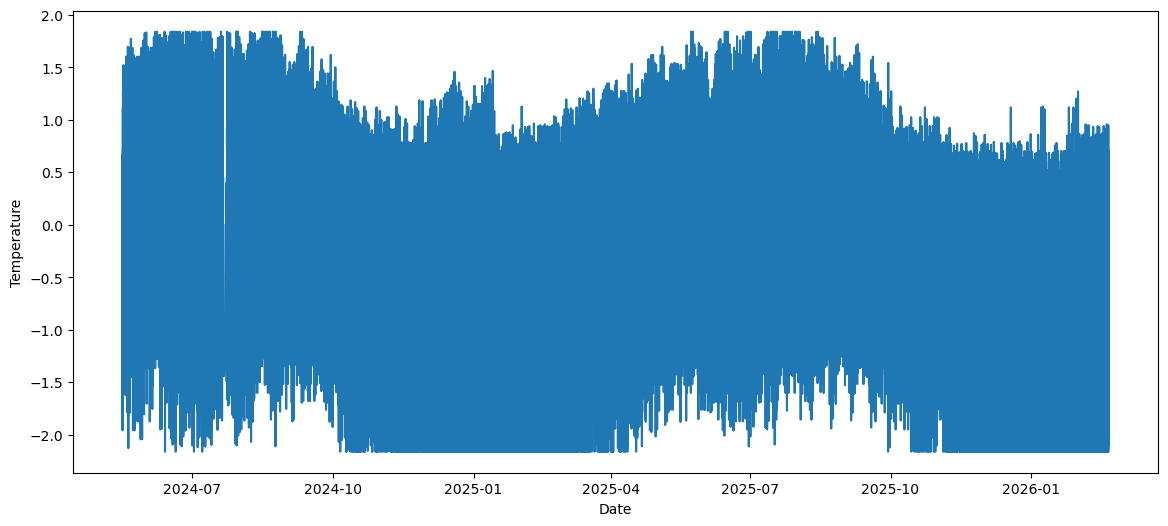

In [11]:
#Temperature trend

import matplotlib.pyplot as plt
plt.figure(figsize = (14,6))
plt.plot(df.index, df['temperature_celsius'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

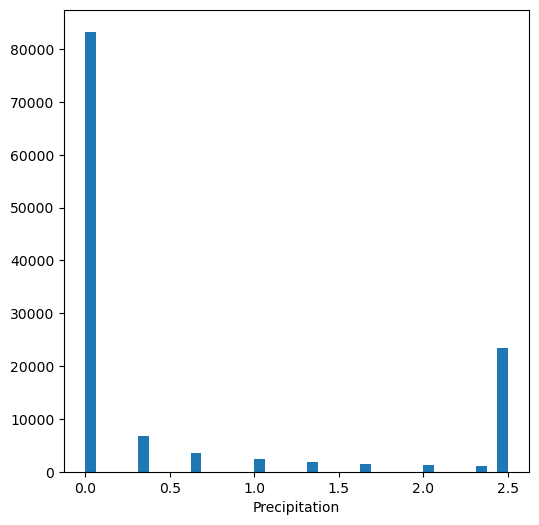

In [12]:
#Precipitation trend
plt.figure(figsize = (6,6))
#plt.plot(df.index, df['precip_mm'])
plt.hist(df['precip_mm'], bins = 40)
plt.xlabel('Precipitation')
plt.show()

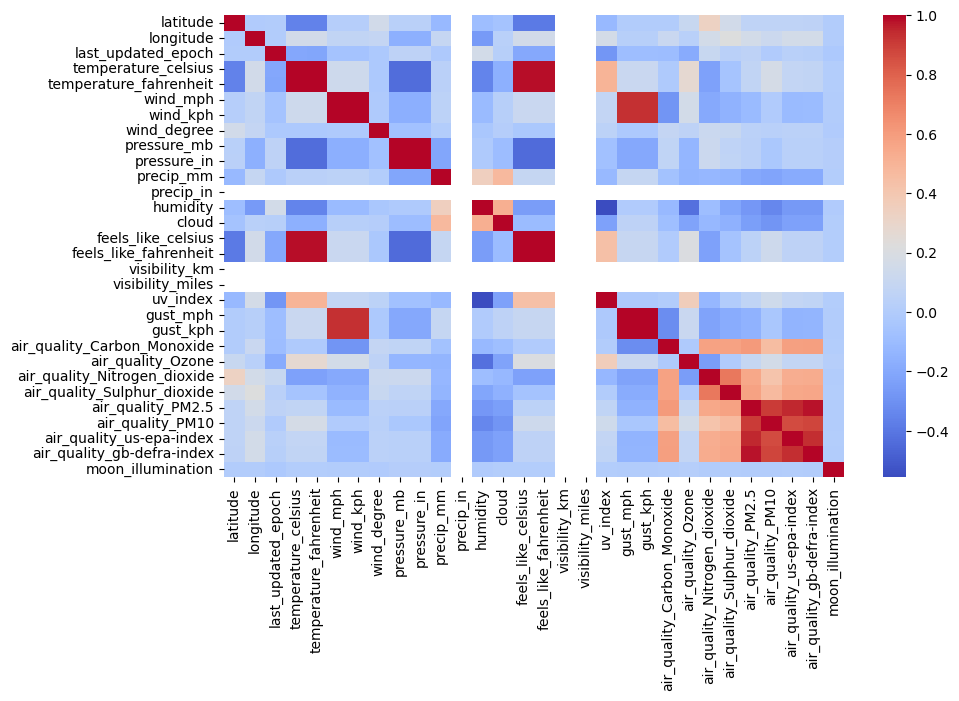

In [13]:
import seaborn as sns
plt.figure(figsize = (10,6))
sns.heatmap(df[temp_df].corr(), cmap='coolwarm')
plt.show()

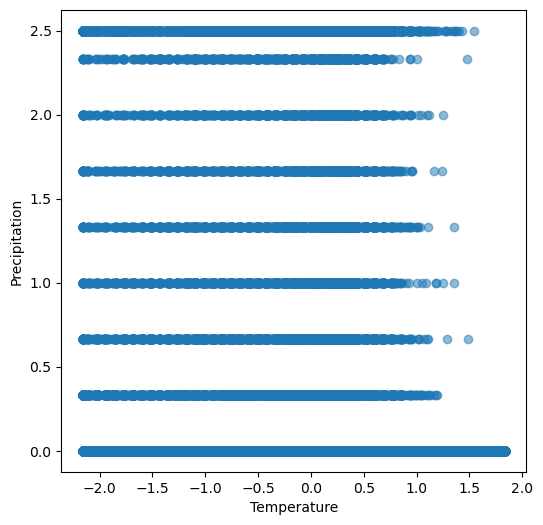

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(df['temperature_celsius'], df['precip_mm'], alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Precipitation")
plt.show()


In [15]:
df['year'] = df.index.year
df['month'] = df.index.month

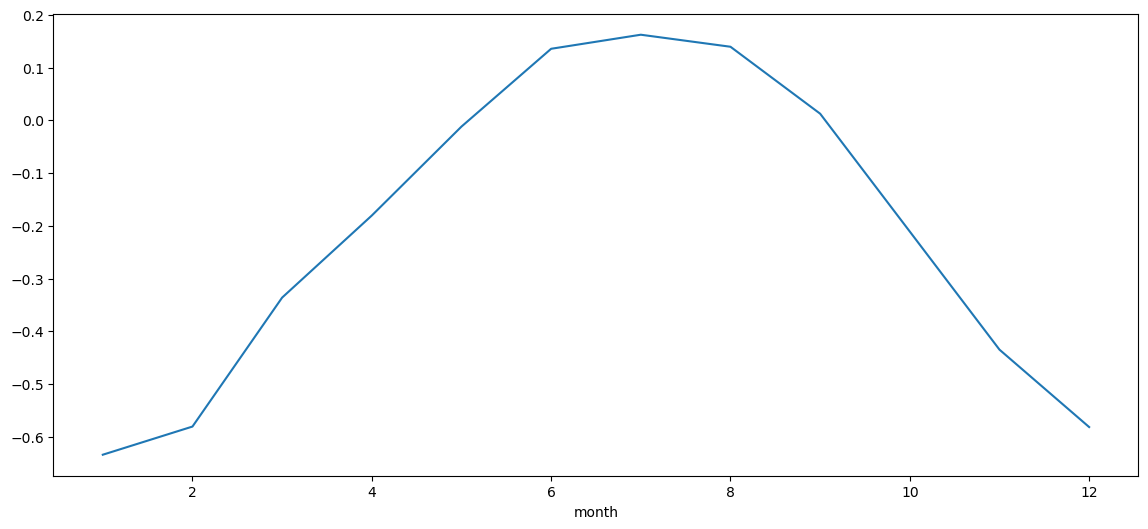

In [16]:
monthly_temp = df.groupby('month')['temperature_celsius'].mean()
plt.figure(figsize = (14,6))
plt.xlabel('month')
plt.plot(monthly_temp)
plt.show()

C:\Users\rajas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rajas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


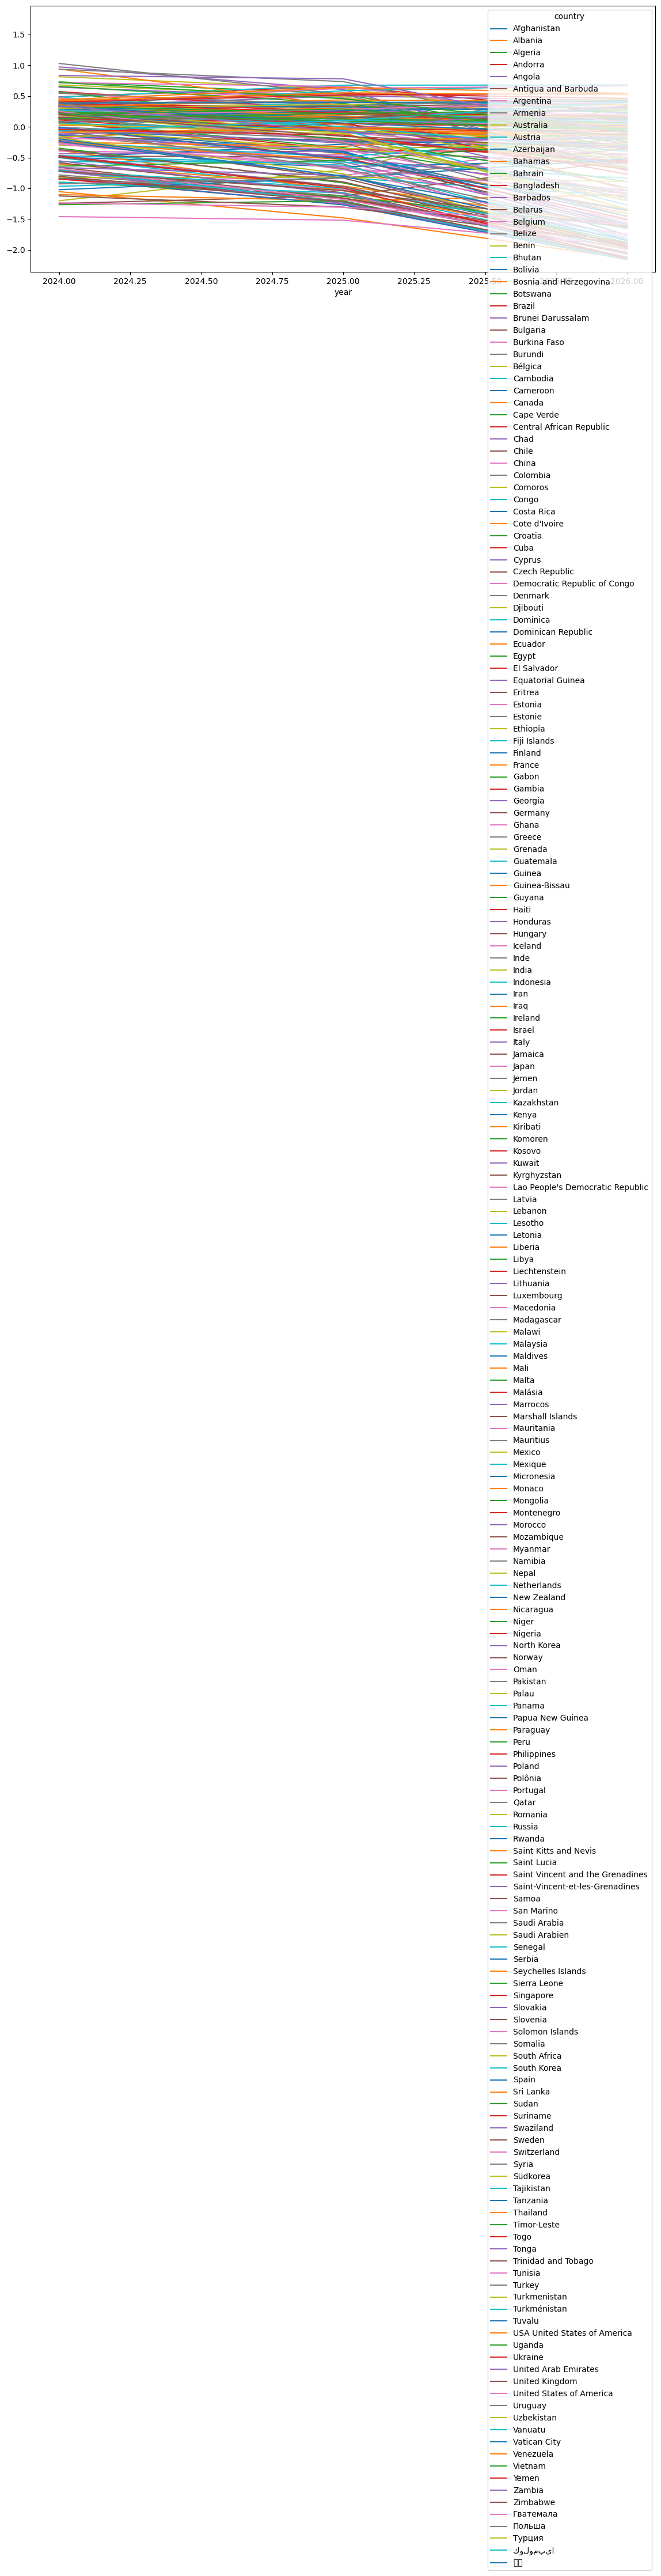

In [17]:
region = df.groupby(['country','year'])['temperature_celsius'].mean().unstack()
region.T.plot(figsize = (14,6))
plt.show()

## Model Building

In [24]:
train = df.iloc[:80]
test = df.iloc[20:]

X_train = train.drop(columns=['temperature_celsius'])
y_train = train['temperature_celsius']

X_test = test.drop(columns=['temperature_celsius'])
y_test = test['temperature_celsius']

In [26]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
arima_model = ARIMA(train['temperature_celsius'], order=(4,1,0))  
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))


C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

In [29]:

sarima_model = SARIMAX(
    train['temperature_celsius'],
    order=(5,1,0),               
    seasonal_order=(1,1,1,12)    
)
sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.forecast(steps=len(test))


C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\rajas\anaconda3\Lib\sit

In [28]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [30]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 11.2 MB/s eta 0:00:09
   - -------------------------------------- 3.9/101.7 MB 10.7 MB/s eta 0:00:10
   -- ------------------------------------- 6.6/101.7 MB 10.6 MB/s eta 0:00:09
   --- ------------------------------------ 8.4/101.7 MB 10.0 MB/s eta 0:00:10
   --- ------------------------------------ 10.0/101.7 MB 9.4 MB/s eta 0:00:10
   ---- ----------------------------------- 12.1/101.7 MB 9.4 MB/s eta 0:00:10
   ----- ---------------------------------- 14.2/101.7 MB 9.4 MB/s eta 0:00:10
   ------ --------------------------------- 15.7/101.7 MB 9.2 MB/s eta 0:00:10
   ------ --------------------------------- 17.3/101.7 MB 8.9 MB/s eta 0:00:10
   ------- -------------------------------- 18.9/101.7 MB 8.8 MB/s eta 0:00:10
   ------- -------------------------------- 19.7/101.7 MB 8.3 MB/s eta 0:00:10
   -------- ------------------------------- 20.4/101.7 MB 8.

In [31]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_test, arima_pred, "ARIMA")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, sarima_pred, "SARIMA")
evaluate(y_test, xgb_pred, "XGBoost")

ARIMA - MAE: 0.67, RMSE: 0.80
Random Forest - MAE: 0.48, RMSE: 0.62
SARIMA - MAE: 71.53, RMSE: 82.46
XGBoost - MAE: 0.52, RMSE: 0.68
